In [97]:
import ffmpeg
import soundfile as sf
import shign  # Install by instructions here: https://github.com/KnurpsBram/shign/tree/master
from pathlib import Path
from dataclasses import dataclass, field
import numpy as np

from pydub import AudioSegment
from fix_audio_mono import read_audio_file_to_numpy

from scipy.fftpack import fft, ifft, fftshift
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from tqdm import tqdm
from scipy.signal import decimate
from datetime import timedelta
import cupy as cp



In [98]:
def calc_rms(signal):
    return np.sqrt(np.mean(signal ** 2))


def get_sample_rate(audio_file):
    # Probe the audio file
    probe = ffmpeg.probe(audio_file, v='error', select_streams='a:0', show_entries='stream=sample_rate')

    # Extract sample rate from probe result
    sample_rate = probe['streams'][0]['sample_rate']
    return int(sample_rate)


def get_audio_info(filename: str) -> tuple[int, float, str]:
    try:
        # Probe the audio file for sample rate and duration
        probe = ffmpeg.probe(filename, v='error', select_streams='a:0', show_entries='stream=sample_rate,duration')

        # Extract sample rate and duration from the probe result
        sample_rate = int(probe['streams'][0]['sample_rate'])
        duration = float(probe['streams'][0]['duration'])
        codec_name = str(probe['format']['format_name'])

        return sample_rate, duration, codec_name
    except Exception as e:
        raise ValueError(f'Failed to get audio info: {e}')


def write_audio_to_file(audio_data: np.ndarray, sample_rate: int, output_filename: str, codec='flac'):
    # Ensure the audio data is in the correct format (float32 or int16)
    if audio_data.dtype != np.float32:
        audio_data = audio_data.astype(np.float32)

    output_filename = change_extension(output_filename, f'.{codec}')
    print(output_filename)
    print(codec)

    # Create an ffmpeg process to encode the audio with the given bitrate
    (
        ffmpeg
        .input('pipe:0', format='f32le',
               ac=1)  # f32le for float32 little endian, 'ac=1' for mono, adjust for stereo if needed
        .output(output_filename, acodec=codec, ar=sample_rate)  # Specify bitrate and codec (aac)
        .run(input=audio_data.tobytes())  # Send the audio data as a byte stream
    )
    
    return output_filename


def cut_audio(input_file, output_file, start_time, end_time, bitrate=None, codec=None):
    """
    Cut an audio file between two timestamps using the ffmpeg-python library.
    
    :param input_file: Path to the input audio file
    :param output_file: Path to the output audio file
    :param start_time: Start time in the format "hh:mm:ss" or seconds (e.g., "00:01:30" or "90")
    :param end_time: End time in the format "hh:mm:ss" or seconds (e.g., "00:02:30" or "150")
    """

    bitrate = 0 if bitrate is None else bitrate
    codec_to_use = 'copy' if codec is None else codec

    try:
        sample_rate, duration, codec_name = get_audio_info(input_file)
    except Exception as ex:
        return 'Cannot probe: ->' + str(ex), None, False

    args = 'No args'
    try:
        start_time = '0' if start_time is None else start_time
        end_time = str(timedelta(0, duration)) if end_time is None else end_time

        # Special addition to circumvent bug in ffmpeg copying of FLAC streams, to force recoding
        if f'{codec_to_use}_{codec_name}'.upper() == 'COPY_FLAC':
            codec_to_use = 'flac'

        stream = (
            ffmpeg
            .input(input_file, ss=start_time, to=end_time)  # Input file with start and end times
            .output(output_file, codec=codec_to_use, ar=bitrate)  # Copy codec (no re-encoding)
            .overwrite_output()
        )

        args = stream.get_args()
        out, err = stream.run(capture_stdout=True, capture_stderr=True)
        return err.decode('utf-8'), args, True
    except ffmpeg.Error as error:
        return error.stderr.decode("utf-8"), args, False


def change_extension_by_file(file1, file2):
    """
    Change the extension of file2 to match the extension of file1 and return the new filename.
    
    :param file1: Path to the first file (used to determine the new extension)
    :param file2: Path to the second file (the file whose extension will be changed)
    :return: The new filename with the updated extension
    """
    # Create Path objects
    # Get the extension of file1
    ext1 = Path(file1).suffix

    # Create the new filename with the extension of file1
    new_file2 = change_extension(file2, ext1)

    # Return the new filename
    return str(new_file2)


def change_extension(file, new_extension):
    filepath = Path(file)
    new_file_name = filepath.with_suffix(new_extension)
    return str(new_file_name)


def add_suffix_to_filename(file_path: str, suffix: str) -> str:
    # Create a Path object from the given file path
    path = Path(file_path)

    # Create the new file name with suffix before the extension
    new_name = f"{path.stem}_{suffix}{path.suffix}"

    # Combine the directory with the new name
    new_path = path.with_name(new_name)

    return str(new_path)


def calculate_shift(signal, shift):
    if shift < 0:
        # Shift signal_b to the right (negative lag)
        shifted = np.roll(signal, shift)
        # shifted_b[-shift:] = 0  # Zero-pad the end
        shifted[shift:] = 0  # Zero-pad the end
    elif shift > 0:
        # Shift signal_b to the left (positive lag)
        shifted = np.roll(signal, shift)
        # shifted_b[:shift] = 0  # Zero-pad the start
        shifted[0:shift] = 0  # Zero-pad the start
    else:
        # No shift
        shifted = signal
    return shifted


def calc_str_from_timestamp(timestamp: str) -> str:
    timestamp_str = timestamp.replace(':', '_')
    timestamp_str = f'({timestamp_str})'
    return timestamp_str


def plot_correlations(shifts_x, correlations, title, xlabel, ylabel):
    plt.figure(figsize=(10, 6))
    plt.plot(shifts_x, correlations, color='purple')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def display_two_signals(audio_a, audio_b, sampling_rate=48000):
    time_a = np.linspace(0, len(audio_a) / sampling_rate, num=len(audio_a))
    time_b = np.linspace(0, len(audio_b) / sampling_rate, num=len(audio_b))

    # Create the plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # Plot the first signal
    ax1.plot(time_a, audio_a, color='blue')
    ax1.set_title('Audio Signal 1')
    ax1.set_ylabel('Amplitude')

    # Plot the second signal
    ax2.plot(time_b, audio_b, color='green')
    ax2.set_title('Audio Signal 2')
    ax2.set_xlabel('Time [seconds]')
    ax2.set_ylabel('Amplitude')

    # Adjust layout and display the plot
    plt.tight_layout()
    plt.show()


def calc_corr_after_shift(signal_a, signal_b, shift):
    shifted_b = calculate_shift(signal_b, shift)
    correlation = r2_score(signal_a, shifted_b)
    return correlation




In [99]:
@dataclass
class AudioFile:
    filename: str
    duration: float = field(init=False)  # Exclude from the generated __init__ method
    sample_rate: int = field(init=False)  # Exclude from the generated __init__ method
    sample_rate_output: int = field(init=False)  # Exclude from the generated __init__ method
    codec: str = field(init=False)  # Exclude from the generated __init__ method

    def create_audio_slice_name(self, start_time, end_time):
        start_time_str = calc_str_from_timestamp(start_time)
        end_time_str = calc_str_from_timestamp(end_time)

        new_filename = add_suffix_to_filename(self.filename, start_time_str)
        new_filename = add_suffix_to_filename(new_filename, end_time_str)

        return new_filename

    def create_audio_slice(self, start_time, end_time):
        new_filename = self.create_audio_slice_name(start_time, end_time)
        codec_to_use = None  # Default: use only copy
        if self.sample_rate != self.sample_rate_output:
            codec_to_use = 'flac'
            new_filename = change_extension(new_filename, '.flac')

        if not Path(new_filename).exists():
            cut_audio(self.filename, new_filename, start_time, end_time, bitrate=self.sample_rate_output,
                      codec=codec_to_use)
        return new_filename

    def set_sample_rate_output(self, rate1, rate2):
        self.sample_rate_output = max(rate1, rate2)

    def __post_init__(self):
        # Calculate sample rate from filename
        self.sample_rate, self.duration, self.codec = get_audio_info(self.filename)

        # Validation
        if self.sample_rate <= 0:
            raise ValueError('Sample rate must be a positive integer.')
        if self.duration < 0:
            raise ValueError('Duration cannot be negative.')



In [106]:
# Example usage:
input_file_1 = r'F:\Experiments\TMNT.mp2'
output_file_1 = r'F:\Experiments\TMNT_out.mp2'
# output_file_1 = change_extension(input_file_1, output_file_1)

# input_file_2 = r'F:\Experiments\TMNT_41k.flac'
input_file_2 = r'F:\Experiments\TMNT_41k_cut37sec_withnoise.flac'
output_file_2 = r'F:\Experiments\TMNT_41k_cut37sec_withnoise_out.flac'
# output_file_2 = change_extension(input_file_2, output_file_2)

start_time = '00:11:30'  # Start at 1 minute 30 seconds
end_time = '00:26:30'  # End   at 2 minutes 30 seconds

# cut_audio(input_file_1, output_file_1, start_time, end_time)
# cut_audio(input_file_2, output_file_2, start_time, end_time)
# 
# print(get_sample_rate(output_file_1))
# print(get_sample_rate(output_file_2))


In [109]:
# ffmpeg_output, ffmpeg_args, success = cut_audio(input_file_1, output_file_1, start_time, end_time)
# print(success, ffmpeg_args)
# print(ffmpeg_output)
# 
# ffmpeg_output, ffmpeg_args, success = cut_audio(input_file_2, output_file_2, start_time, end_time)
# print(success, ffmpeg_args)
# print(ffmpeg_output)

True ['-ss', '00:11:30', '-to', '00:26:30', '-i', 'F:\\Experiments\\TMNT.mp2', '-ar', '0', '-codec', 'copy', 'F:\\Experiments\\TMNT_out.mp2', '-y']
ffmpeg version 7.0.2-full_build-www.gyan.dev Copyright (c) 2000-2024 the FFmpeg developers
  built with gcc 13.2.0 (Rev5, Built by MSYS2 project)
  configuration: --enable-gpl --enable-version3 --enable-static --disable-w32threads --disable-autodetect --enable-fontconfig --enable-iconv --enable-gnutls --enable-libxml2 --enable-gmp --enable-bzlib --enable-lzma --enable-libsnappy --enable-zlib --enable-librist --enable-libsrt --enable-libssh --enable-libzmq --enable-avisynth --enable-libbluray --enable-libcaca --enable-sdl2 --enable-libaribb24 --enable-libaribcaption --enable-libdav1d --enable-libdavs2 --enable-libuavs3d --enable-libxevd --enable-libzvbi --enable-librav1e --enable-libsvtav1 --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxavs2 --enable-libxeve --enable-libxvid --enable-libaom --enable-libjxl --enable-libopenjpe

In [117]:
audio_1 = AudioFile(input_file_1)
audio_2 = AudioFile(input_file_2)
audio_1.set_sample_rate_output(audio_1.sample_rate, audio_2.sample_rate)
audio_2.set_sample_rate_output(audio_1.sample_rate, audio_2.sample_rate)

output_file_1_name = audio_1.create_audio_slice(start_time, end_time)
output_file_2_name = audio_2.create_audio_slice(start_time, end_time)

print(f'{output_file_1_name}\n{output_file_2_name}')


F:\Experiments\TMNT_(00_11_30)_(00_26_30).mp2
F:\Experiments\TMNT_41k_cut37sec_withnoise_(00_11_30)_(00_26_30).flac


In [118]:

# audio_a, audio_b = shign.shift_align(
#     output_file_1_name,
#     output_file_2_name,
#     align_how='crop_both',
#     min_overlap_sec=20,
#     # max_shift_sec=args["max_shift_sec"]
# )

audio_a_rate, audio_a = read_audio_file_to_numpy(output_file_1_name, True, True)
audio_b_rate, audio_b = read_audio_file_to_numpy(output_file_2_name, True, True)
# audio_a = audio_a.T
# audio_b = audio_b.T

In [119]:
audio_a.shape, audio_a_rate, audio_b.shape, audio_b_rate, audio_a.max(), audio_b.max()

# output_file_1_name

((43200000, 1), 48000, (43200000, 1), 48000, 0.262, 0.4575)

In [35]:
import numpy as np


# Assuming audio_a and audio_b are your numpy arrays containing the audio signals
# For example:
# audio_a = np.sin(2 * np.pi * np.linspace(0, 1, 1000))  # Example signal
# audio_b = np.cos(2 * np.pi * np.linspace(0, 1, 1000))  # Example signal

# Create a time axis assuming the sampling rate is the same for both signals
# Use np.linspace to create the time axis based on the length of audio arrays


def normalize(signal):
    signal_no_dc = signal - np.mean(signal)
    return signal_no_dc / np.max(np.abs(signal_no_dc))


def normalize_by_rms(signal: np.ndarray) -> np.ndarray:
    # Compute the RMS value
    sig = signal - np.mean(signal)  # Remove dc signal
    rms = np.sqrt(np.mean(np.square(sig)))

    # Avoid division by zero if RMS is zero
    if rms == 0:
        return signal  # or return np.zeros_like(signal) if you prefer zero output

    # Normalize the signal
    normalized_signal = sig / rms

    return normalized_signal

# display_two_signals(audio_a, audio_b, 48000)

In [38]:
# Note the filename is returned because it might be changed according to the codec
shifted_audio_file_name_1 = add_suffix_to_filename(output_file_1_name, 'shifted')
shifted_audio_file_name_1 = write_audio_to_file(audio_a, audio_1.sample_rate_output, shifted_audio_file_name_1) 

shifted_audio_file_name_2 = add_suffix_to_filename(output_file_2_name, 'shifted')
shifted_audio_file_name_2 = write_audio_to_file(audio_b, audio_2.sample_rate_output, shifted_audio_file_name_2) 


F:\Experiments\output_audio_1_(00_01_30)_(00_06_30)_shifted.flac
flac
F:\Experiments\output_audio_2b_(00_01_30)_(00_06_30)_shifted.flac
flac


In [120]:
decimation_factor = 2

def cut_slices(signals, start, end):
    return (signal[start:end,:] for signal in signals)


def normalized_slices(signals, start, end, should_normalize=True):
    slices = cut_slices(signals, start, end)
    print(','.join(str(signal.shape) for signal in signals))
    slices = (decimate(signal, decimation_factor,axis=0) for signal in slices)
    if should_normalize:
        slices = (normalize(signal) for signal in slices)
        # slices = (normalize_by_rms(signal) for signal in slices)
    # slices = (signal.astype(np.float16) for signal in slices)
    return slices


_, audio_a_from_file = read_audio_file_to_numpy(output_file_1_name, True, True)
_, audio_b_from_file = read_audio_file_to_numpy(output_file_2_name, True, True)


# no_samples_slice = no_seconds_slice * audio_1.sample_rate_output
no_seconds_slice = 1000
no_samples_slice = no_seconds_slice * audio_1.sample_rate_output  #audio_a.shape[0]
sample_start = 0
(audio_a_slice, audio_b_slice) = normalized_slices((audio_a_from_file, audio_b_from_file), sample_start,
                                                   sample_start + no_samples_slice,
                                                   True)


# (audio_a_slice, audio_b_slice) = normalized_slices((audio_a, audio_b), 0, audio_a.shape[0])

(43200000, 1),(43200000, 1)


In [215]:
audio_a_from_file_reshaped = np.squeeze(audio_a_from_file)
audio_b_from_file_reshaped = np.squeeze(audio_b_from_file)
shift = shign.get_shift_ms(audio_a_trfrom_file_reshaped, audio_b_from_file_reshaped, 48000, 48000,  hop_length_ms=1.0, min_overlap_sec=100,  max_shift_sec=0) # , win_length_ms=25., hop_length_ms=10., min_overlap_sec=1., max_shift_sec=30.
shift

-899974.0

In [213]:
np.squeeze(audio_a_from_file).shape

(43200000,)

In [154]:
import scipy.signal

corr = scipy.signal.correlate(audio_a_from_file, audio_b_from_file)
corr = np.nan_to_num(corr,0.0) # For some reason there could be NaN in the result
corr /= np.max(corr)

lags = scipy.signal.correlation_lags(len(audio_a_from_file), len(audio_b_from_file))
seconds = lags/ 48000

audio_a_from_file.shape, corr.shape, corr.argmax(), corr[corr.argmax()], seconds[corr.argmax()] 
# 37 seconds should be 888000 samples, which should be at location 11859429



((43200000, 1),
 (86399999, 1),
 44975985,
 array([1.], dtype=float16),
 36.99970833333333)

In [155]:
zero_index = np.where(seconds == 0.0)[0][0]
t37_index = np.where(seconds == 37.0)[0][0]
center_index = corr.argmax()


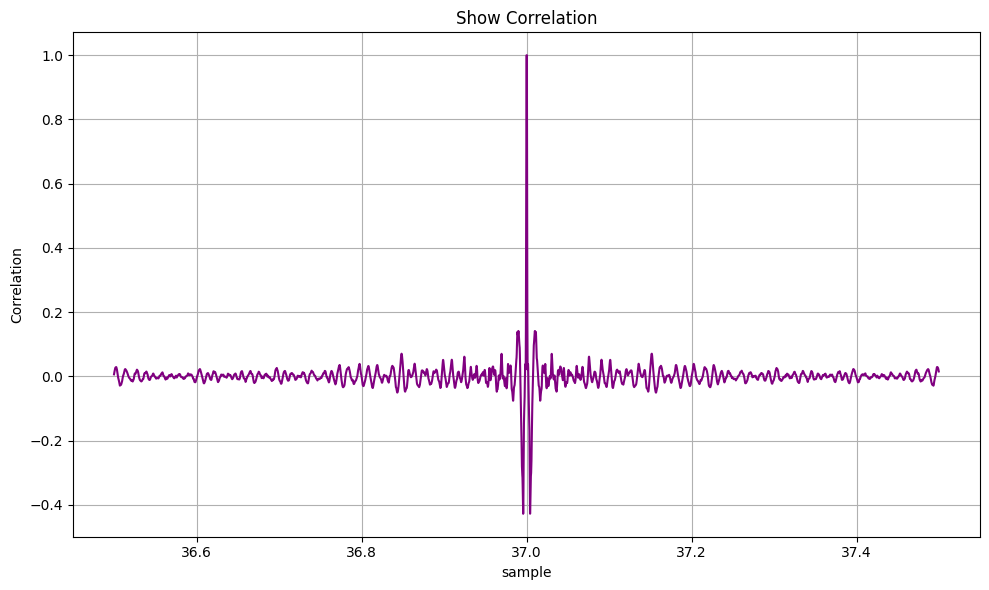

In [156]:
plot_correlations(seconds[(center_index-24000):(center_index+24000)], corr[(center_index-24000):(center_index+24000)], "Show Correlation", 'sample', 'Correlation')
# seconds[len(corr)//2-4:len(corr)//2+4]

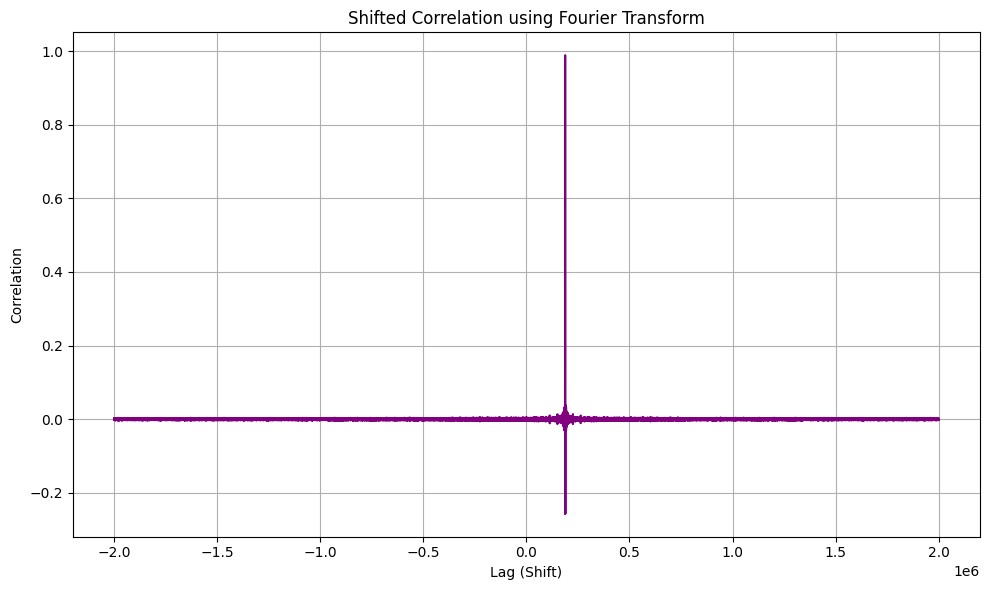

best shift: 188160, R2=0.9884413480758667, calculated R2: 0.9863595366477966


In [49]:
siz = correlations.shape[0] // 2
plot_correlations(shifts[siz - 2000000:siz + 2000000], correlations[siz - 2000000:siz + 2000000],
                  'Shifted Correlation using Fourier Transform', 'Lag (Shift)',
                  'Correlation')

corr = calc_corr_after_shift(audio_a_slice, audio_b_slice, best_shift)
print(f'best shift: {best_shift}, R2={best_corr}, calculated R2: {corr}')

5085.405405405405

In [17]:
audio_b_slice_shifted = calculate_shift(audio_b, best_shift)
output_file_shifted = add_suffix_to_filename(input_file_2, 'shifted')
write_audio_to_file(audio_b_slice, audio_1.sample_rate_output,
                    output_filename=output_file_shifted,
                    codec='flac')

F:\Experiments\TMNT_41k_shifted.flac
flac


In [18]:
audio_b_slice.shape[0], audio_b_slice_shifted.shape[0]

(93504480, 187008960)

In [19]:
# #
# import sounddevice as sd
# 
# sd.play(audio_b, samplerate=audio_1.sample_rate_output)
# sd.wait()

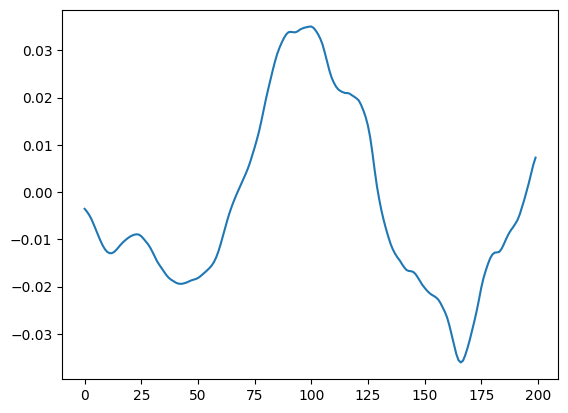

In [20]:
plt.plot(correlations[best_correlation_index - 100:best_correlation_index + 100])


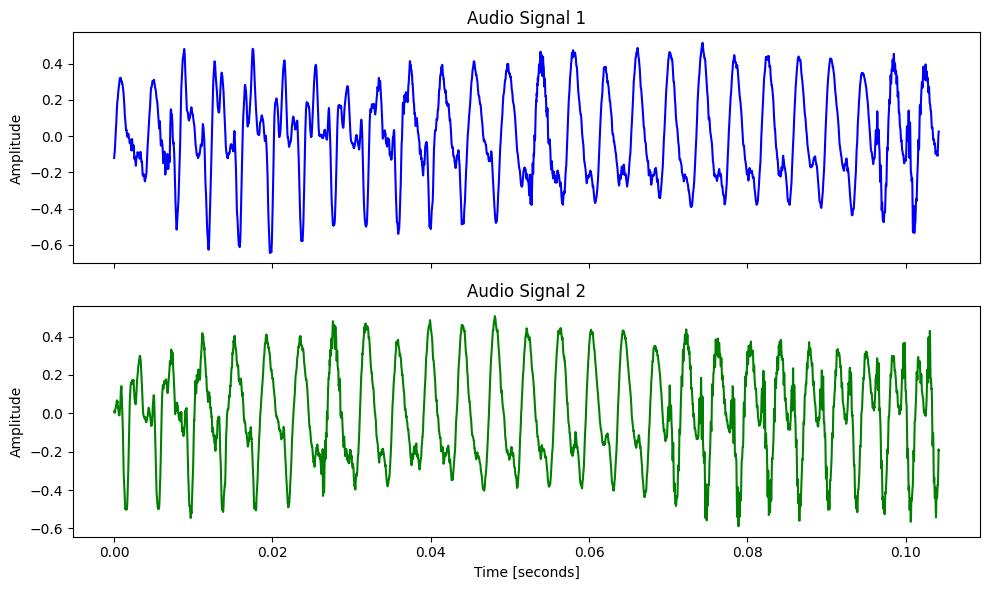

In [21]:
audio_b_slice_shifted = calculate_shift(audio_b_slice, best_shift)
diff = (audio_a_slice - audio_b_slice_shifted) / 2
display_two_signals(audio_a_slice[5000:10000], audio_b_slice_shifted[5000:10000], 48000)

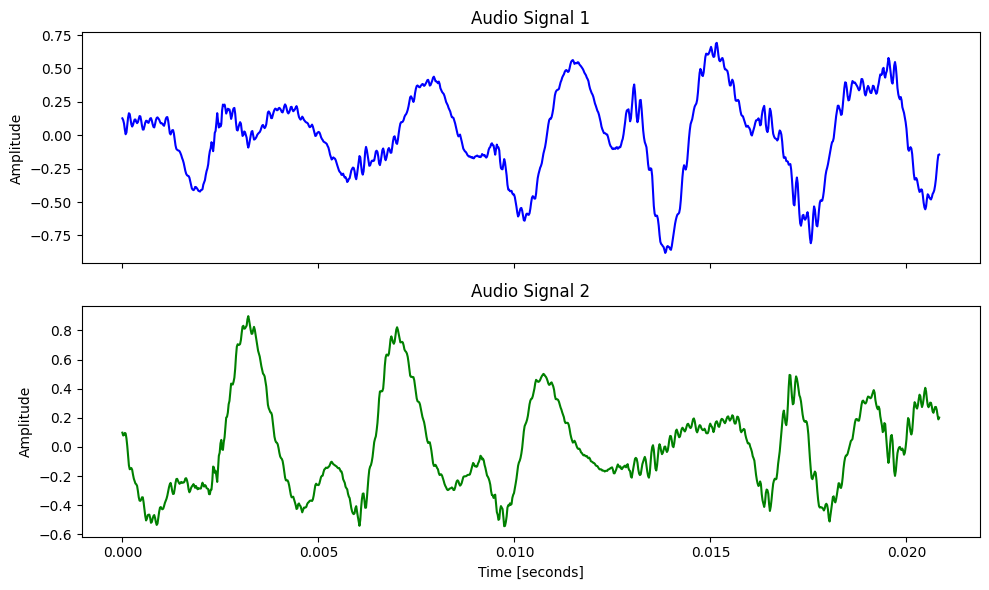

In [22]:
a, b = audio_a_slice[9000:10000], audio_b_slice_shifted[9000:10000]
a, b = normalize(a), normalize(b)
difference = (a - b) / 2
summ = (a + b) / 2
display_two_signals(summ, difference, 48000)

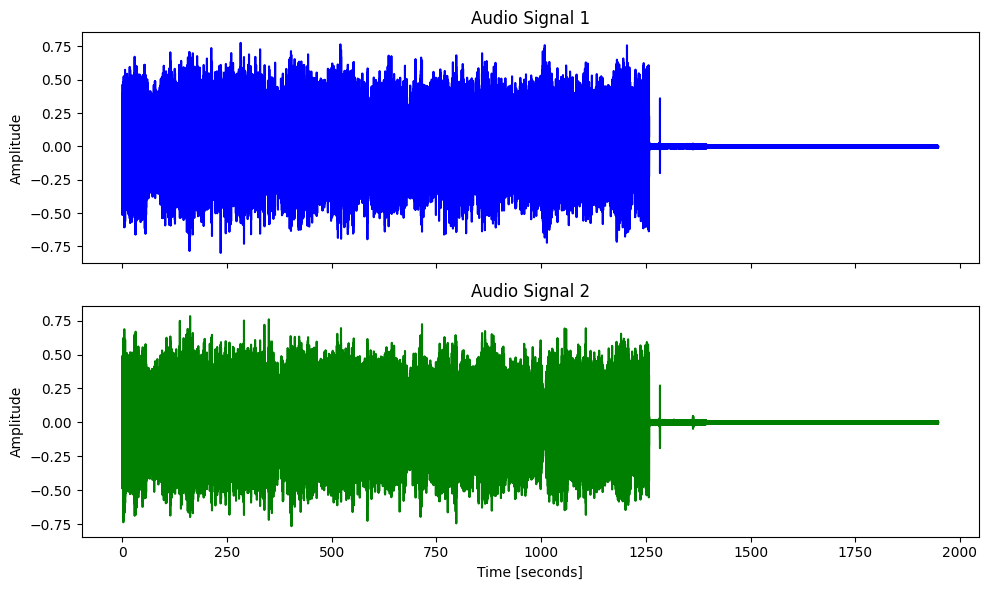

RMS of avg = 0.08020412
RMS of diff= 0.0793722


In [23]:
audio_b_slice_shifted = calculate_shift(audio_b_slice, best_shift)
avg = (audio_a_slice + audio_b_slice_shifted) / 2
diff = (audio_a_slice - audio_b_slice_shifted) / 2
display_two_signals(avg, diff, 48000)

print(f'RMS of avg =', calc_rms(avg))
print(f'RMS of diff=', calc_rms(diff))


In [24]:
# # Compute shifted correlation
# shifted_corr = shifted_correlation_fft(audio_a_slice, audio_b_slice)
# 
# plot_correlations(shifts, shifted_corr, 'Shifted Correlation using Fourier Transform', 'Lag (Shift)', 'Correlation')
# 
# best_correlation_index = np.argmax(shifted_corr)
# best_shift = shifts[best_correlation_index]
# best_corr = shifted_corr[best_correlation_index]
# 
# print(best_shift, shifted_corr[np.argmax(shifted_corr)])